# Advanced Demand Forecasting for STN_0003
This notebook combines the initial data loading from `04__modeling_lvl1.ipynb` with advanced feature engineering and predictive modeling using Prophet and XGBoost.

## 1. Environment Setup & Data Loading
Initializing Spark and loading the silver-level ride data.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

plt.rcParams['figure.figsize'] = (12, 5)

spark = SparkSession.builder.appName("inflowOutflowForecast").getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "America/Toronto")

# Load data using paths from the original notebook
rides_df = spark.read.parquet("../../data/silver/rides/", unionByName=True)
rides_df.createOrReplaceTempView("rides")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/03 16:18:58 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.39 instead (on interface en0)
26/04/03 16:18:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/03 16:18:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Data Preparation for STN_0003
Filtering for the specific station and aggregating by hour.

In [2]:
# Filter for STN_0003
stn_df = rides_df.filter(F.col("start_canonical_station_id") == "STN_0003")

# Aggregate to hourly intervals
hourly_df = stn_df.withColumn("hour_ts", F.date_trunc("hour", "start_time_ms")) \
    .groupBy("hour_ts") \
    .agg(F.count("*").alias("outflow")) \
    .orderBy("hour_ts")

# Convert to Pandas for modeling
pdf = hourly_df.toPandas()
pdf.rename(columns={'hour_ts': 'date'}, inplace=True)

## 3. Advanced Feature Engineering
Adding cyclical time features and lag variables to capture temporal patterns.

In [3]:
def perform_feature_engineering(df):
    # 1. Cyclical Time Features
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # 2. Lag Features (1h, 24h, 168h)
    for l in [1, 24, 168]:
        df[f'lag_{l}h'] = df['outflow'].shift(l)
    
    # 3. Rolling Statistics
    df['rolling_mean_3h'] = df['outflow'].rolling(window=3).mean().shift(1)
    
    # 4. Weekend Flag
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    return df.dropna()

pdf_featured = perform_feature_engineering(pdf)

In [4]:
incWeatherFeatures_df = spark.read.parquet("../../data/weather/features_incWeather")
# Show the schema (column names and data types)
incWeatherFeatures_df.printSchema()
# Show the first 5 rows
incWeatherFeatures_df.show(5, truncate=False)

incWeatherFeatures_df.describe().show()
print(f"Total rows: {incWeatherFeatures_df.count()}")

root
 |-- station_id: string (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- demand_count: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- community_id: long (nullable = true)
 |-- temp: float (nullable = true)
 |-- precip: float (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- metro_proximity: string (nullable = true)
 |-- metro_name: string (nullable = true)
 |-- dist_km: double (nullable = true)
 |-- transit_proximity_tier: string (nullable = true)

+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+------------+-----+------+---------+----------+---------------+-------------+-------------------+--------------------------+
|station_id                                                 |ts_hour            |demand_count|day_of_week|is_weekend|is

26/04/03 16:19:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+--------------------+-----------------+-----------------+-------------------+-------------------+------------+------------------+-------------------+-------------------+------------------+---------------+-----------------+--------------------+----------------------+
|summary|          station_id|     demand_count|      day_of_week|         is_weekend|         is_holiday|community_id|              temp|             precip|                lat|               lon|metro_proximity|       metro_name|             dist_km|transit_proximity_tier|
+-------+--------------------+-----------------+-----------------+-------------------+-------------------+------------+------------------+-------------------+-------------------+------------------+---------------+-----------------+--------------------+----------------------+
|  count|             6179615|          6179615|          6179615|            6179615|            6179615|           0|           6141286|            6141286|            61

## 4. Modeling Path A: Prophet
Using Meta's Prophet for additive seasonality modeling.

Importing plotly failed. Interactive plots will not work.
16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:20:06 - cmdstanpy - INFO - Chain [1] done processing
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


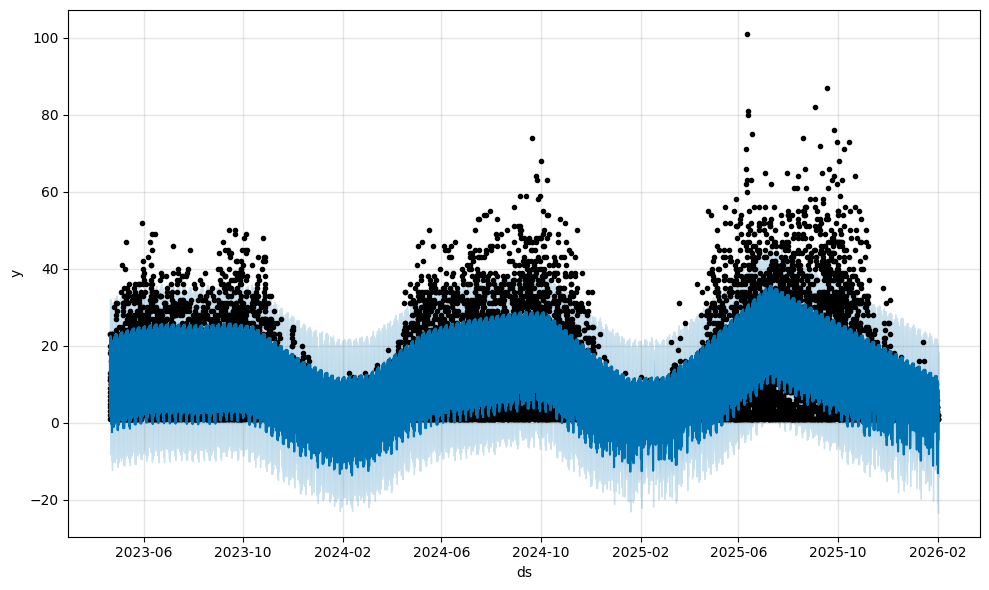

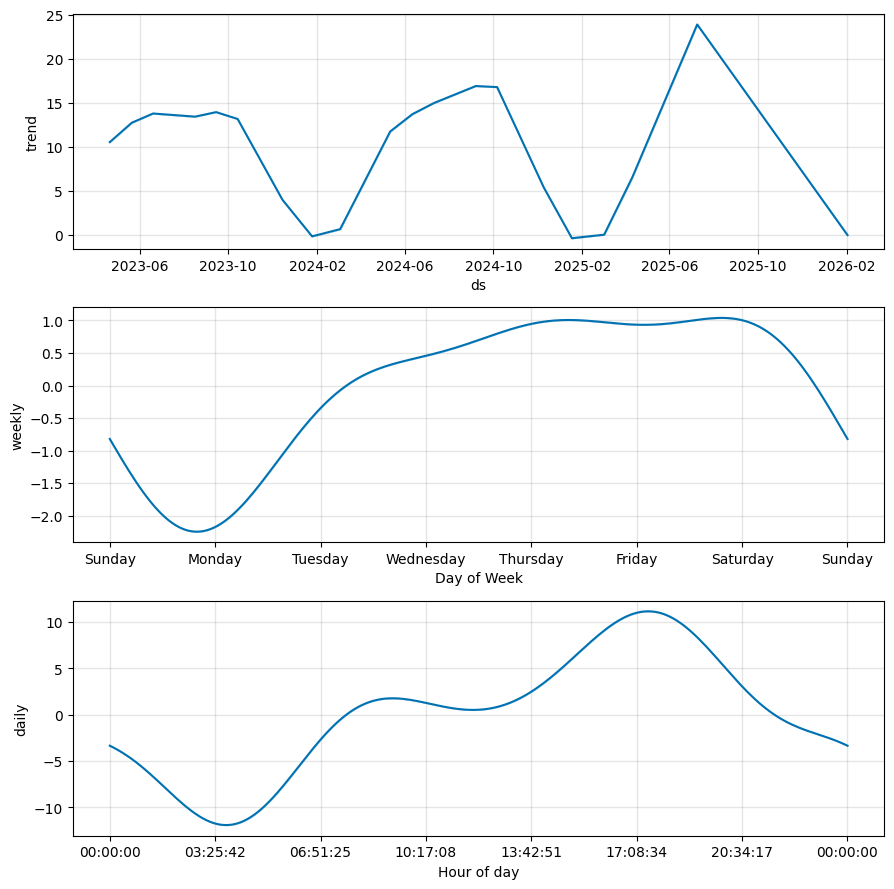

In [5]:
from prophet import Prophet

def train_prophet_model(df, target='outflow'):
    m_df = df[['date', target]].rename(columns={'date': 'ds', target: 'y'})
    
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=True
    )
    model.fit(m_df)
    
    future = model.make_future_dataframe(periods=24, freq='H')
    forecast = model.predict(future)
    
    return model, forecast

model_p, forecast_p = train_prophet_model(pdf_featured)
fig1 = model_p.plot(forecast_p)
fig2 = model_p.plot_components(forecast_p)

In [6]:
incWeatherFeatures_df.createOrReplaceTempView("weather_features")
incWeatherFeatures_df.show(5, truncate=False)
# weather_pdf = incWeatherFeatures_df.toPandas()
# weather_pdf['date'] = pd.to_datetime(weather_pdf['date'])
# weather_pdf.set_index('date', inplace=True)
# weather_pdf = weather_pdf.resample('H').ffill().reset_index()

+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+------------+-----+------+---------+----------+---------------+-------------+-------------------+--------------------------+
|station_id                                                 |ts_hour            |demand_count|day_of_week|is_weekend|is_holiday|community_id|temp |precip|lat      |lon       |metro_proximity|metro_name   |dist_km            |transit_proximity_tier    |
+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+------------+-----+------+---------+----------+---------------+-------------+-------------------+--------------------------+
|45.524790,-73.565450|calixa-lavallée / sherbrooke          |2024-06-24 16:00:00|9           |2          |0         |1         |NULL        |21.4 |0.0   |45.52479 |-73.56545 |High           |Sherbrooke   |0.7256533163973264 |Tier 2: Commuter

In [ ]:
from prophet import Prophet
import pandas as pd

def train_weather_prophet_model(df, target='demand_count'):
    
    # ✅ 1. Convert Spark → Pandas (IMPORTANT)
    if 'pyspark.sql.dataframe.DataFrame' in str(type(df)):
        df = df.toPandas()

    # # ✅ 2. Ensure datetime format
    # df['ts_hour'] = pd.to_datetime(df['ts_hour'])

    # ✅ 3. Rename for Prophet
    m_df = df[['ts_hour', target]].rename(columns={
        'ts_hour': 'ds',
        target: 'y'
    })

    # ✅ 4. Sort (VERY IMPORTANT for time series)
    m_df = m_df.sort_values('ds')

    # ✅ 5. Initialize model
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=True
    )

    # ✅ 6. Train
    model.fit(m_df)

    # ✅ 7. Future dataframe
    future = model.make_future_dataframe(
        periods=24,   # next 24 hours
        freq='h'      # ⚠️ use 'h', not 'H'
    )

    # ✅ 8. Predict
    forecast = model.predict(future)

    return model, forecast

weather_model_p, weather_forecast_p = train_weather_prophet_model(incWeatherFeatures_df)
wfig1 = weather_model_p.plot(weather_forecast_p)ß
wfig2 = weather_model_p.plot_components(weather_forecast_p)

PySparkAttributeError: [ATTRIBUTE_NOT_SUPPORTED] Attribute `rename` is not supported.

## 5. Modeling Path B: XGBoost
Using Gradient Boosted Trees for non-linear regression based on engineered features.

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_53135/3703063183.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(X_test)


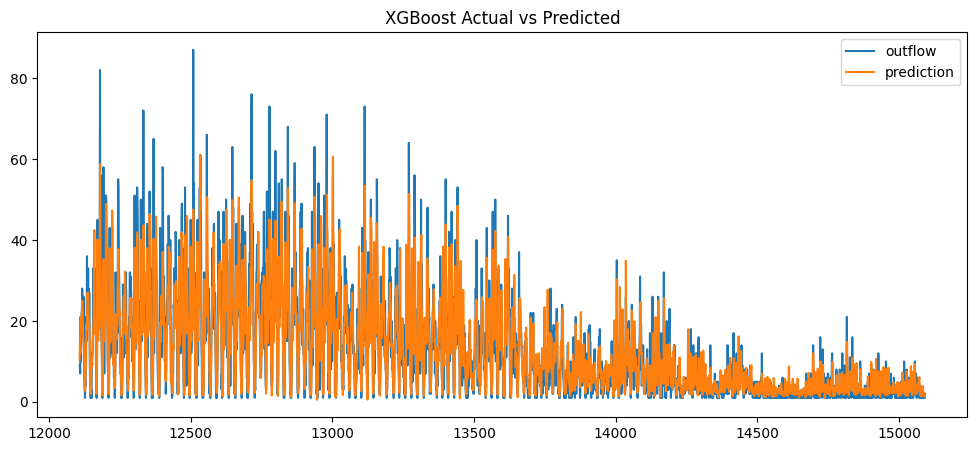

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

def train_xgboost(df, target='outflow'):
    features = ['hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 
                'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_3h']
    
    split_idx = int(len(df) * 0.8)
    train, test = df.iloc[:split_idx], df.iloc[split_idx:]
    
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]
    
    reg = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        early_stopping_rounds=50
    )
    
    reg.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    # Forecast Visualization
    test['prediction'] = reg.predict(X_test)
    test[['outflow', 'prediction']].plot(title="XGBoost Actual vs Predicted")
    
    return reg

model_xgb = train_xgboost(pdf_featured)